In [1]:
print("Hello, World!")

Hello, World!


##### **Text To Text model**

OpenAI, Anthropic models are PAID i.e. when we read these models from their respective servers using their specific keys, these are PAID

We want some free options

If we use our own servers, we can get them for free

How to configure using our own server?
1) Ollama
2) HuggingFace

**Analogies**
- Git: Meant for version control . GitHUB : Platform where we host our code and code is available in the form of repo
- Docker : meant to convert our applications into images. Docker Hub :  Platform where we can keep our apps as images
- HuggingFace : meant to host models or datasets. HuggingFaceHub : Platform to keep those models and datasets 
- Ollama --> OllamaHub : here we have several models which we can download


We can
- Github --> Download code --> available in local system
- Dockerhub --> Download image --> available in local system
- HuggingFacehub --> Download datasets/models --> available in local system
- Ollamahub --> Download model --> available in local system

Can You download model from OpenAI? --> **NO**

Now if we don't want to take the hassle of configuring the model on our own server, then we can use managed cloud platforms (each having their separate API keys): 
- AWS Bedrock
- Azure Cloudn foundry
- Google Verte AI
- Github API enterprise version

These can be accessed further via LangChain

##### **Text To Text model**

In [11]:
import os
from dotenv import load_dotenv
load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
if OPENAI_API_KEY is None:
    raise ValueError("Environment variable 'OPENAI_API_KEY' is not set")
else:
    os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY
    print("OPENAI_API_KEY is set successfully")

OPENAI_API_KEY is set successfully


In [12]:
from langchain_openai import ChatOpenAI

In [13]:
llm = ChatOpenAI(model="gpt-5-nano")

In [14]:
message = llm.invoke("What is the capital of France?")
message.content

'Paris.'

In [15]:
message

AIMessage(content='Paris.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 203, 'prompt_tokens': 13, 'total_tokens': 216, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 192, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DikP6vf6ejD6EopKmqbjz6BS2wr7o', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e55df-9722-7652-b12b-ac13916fe902-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 203, 'total_tokens': 216, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 192}})

##### **Text To Image model**

In [18]:
llm = ChatOpenAI(model="gpt-5.4-mini")
kwargs = {"type": "image_generation", "quality": "low"}
llm_with_tools = llm.bind_tools([kwargs])
image_message = llm_with_tools.invoke("Draw a picture of a cute fuzzy cat with an umbrella")
image_message

AIMessage(content=[{'id': 'ig_0055549ca435410c006a11e4acc20881969f6667b77788978e', 'result': '...', 'status': 'completed', 'type': 'image_generation_call', 'action': 'generate', 'background': 'opaque', 'output_format': 'png', 'quality': 'low', 'revised_prompt': 'A cute fuzzy cat holding a bright umbrella, whimsical illustration, soft pastel colors, fluffy fur, big sparkling eyes, adorable expression, gentle rain drops, playful and charming composition, clean background, high detail, children’s book style', 'size': '1183x1329'}, {'type': 'text', 'text': '', 'annotations': [], 'id': 'msg_0055549ca435410c006a11e4c164e48196ab72dd11c73c074e', 'phase': 'final_answer'}], additional_kwargs={}, response_metadata={'id': 'resp_0055549ca435410c006a11e4ac1dc881968701a130effdbdcf', 'created_at': 1779557548.0, 'metadata': {}, 'model': 'gpt-5.4-mini-2026-03-17', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17'},

In [19]:
import base64   
from IPython.display import Image

In [20]:
image= next(item for item in image_message.content_blocks if item["type"] == "image")

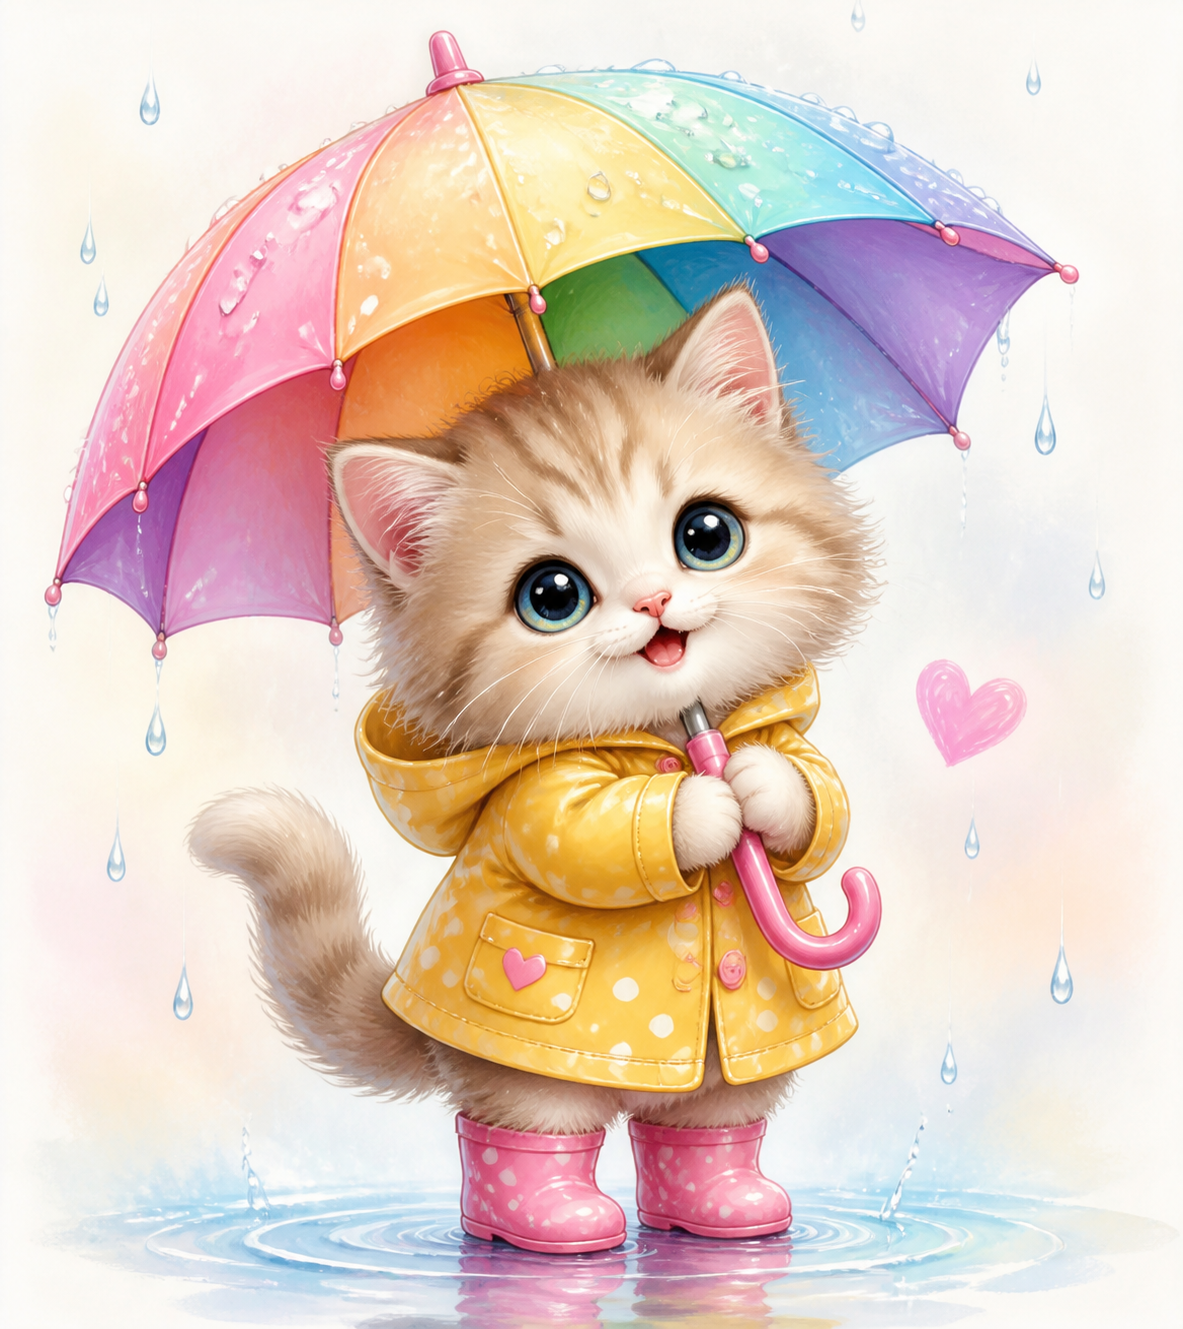

In [21]:
Image(base64.b64decode(image["base64"]), width=200)

##### **Image To Text model**

In [22]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [23]:
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

In [24]:
base64_image = encode_image("C:\Data_science\Modern_route\Images\cats.png")
base64_image

'...'

In [26]:
from langchain_core.messages import HumanMessage

In [27]:
message = HumanMessage(
    content=[
            {"type": "text", "text": "What is in this image?"},
                {
                    "type": "image_url",
                    "image_url": {
                                    "url": f"data:image/png;base64,{base64_image}"
                                },
                },
            ]
)

In [28]:
response = llm.invoke([message])
print(response.content)

The image features a collection of cartoon-style illustrations of cats. Each cat has unique fur colors and patterns, and they exhibit various playful expressions and poses. The background is black, which helps the colorful illustrations stand out. The cats have exaggerated features, such as large eyes and fluffy fur, adding to their whimsical appearance.
